# **FINAL PROJECT** - Does AI Improve Customer Satisfaction?
## **Group 10**: Clément Guyot de La Pommeraye, Erik van der Sangen, Jacopo Cagnacci, Giacomo Bellodi​


## In this notebook we run the sentiment analysis and we finalize the dataset to study.
1. Label 30k random comlplaint with gpt API
2. Train on those gpt labeled complaints a DeBERTa model
3. Validate DeBERTa model
4. Apply the sentiment scoring to remaining 400k complaints.

In [ ]:
#randomly sample 30k observation without balancing
zip_data_16_23_filtered = pd.read_csv('zip_data_16_23_filtered.csv')
data_sample_30k = zip_data_16_23_filtered.sample(n=30000, random_state=42)


## **API CALL ON 30K RANDOM COMPLAINTS**

In [ ]:
#!pip install --upgrade openai

In [2]:
#Import libraries needed
import os
import json
import pandas as pd
from tqdm import tqdm
from openai import OpenAI
import time

In [ ]:
# CONFIGURATION
os.environ["OPENAI_API_KEY"] = "sk- ...."
API_KEY = os.getenv("OPENAI_API_KEY")
MODEL = "gpt-4.1-mini"
TEXT_COL = "Consumer complaint narrative"
BATCH_SIZE = 30
OUTPUT_PARQUET = "cfpb_labeled_30k.parquet"

client = OpenAI(api_key=API_KEY)


In [ ]:
# PROMPT
PROMPT_HEADER = """
You label U.S. consumer complaints about financial institutions.

Given the complaint text, assign:

1) emotional_intensity (1–5):
   1 = mild annoyance
   2 = dissatisfied but calm
   3 = clearly angry or upset
   4 = very angry, strong language or repeated failures
   5 = extreme outrage or life-impacting harm

2) tone (1–5):
   1 = polite
   2 = neutral
   3 = frustrated
   4 = hostile
   5 = threatening

3) harm_severity (1–3):
   1 = none_low
   2 = medium
   3 = high

Return ONLY a JSON object:

{
  "emotional_intensity": <1-5>,
  "tone": <1-5>,
  "harm_severity": <1-3>
}

Return the output as **JSON Lines (JSONL)**:
- One JSON object per complaint
- Same order as provided
- No explanations

Example output (for 2 complaints):
{"emotional_intensity":3,"tone":2,"harm_severity":1}
{"emotional_intensity":5,"tone":4,"harm_severity":3}

Now here are the complaints:
"""

def build_batch_prompt(text_list):
    """Create one long prompt containing all complaints separated by markers."""
    out = PROMPT_HEADER + "\n"
    for i, text in enumerate(text_list):
        out += f"\n--- Complaint {i+1} ---\n{text}\n"
    return out


In [ ]:
df = data_sample_30k.copy()
df = df.dropna(subset=[TEXT_COL])
df.reset_index(drop=True, inplace=True)

print("Number of complaints to label:", len(df))

all_labels = [None] * len(df)


Number of complaints to label: 30000


In [ ]:
# SAFE JSON PARSER
def parse_json_line(line):
    try:
        return json.loads(line)
    except:
        return None



In [ ]:
#  BATCH LOOP
for batch_start in tqdm(range(0, len(df), BATCH_SIZE)):
    batch_end = min(batch_start + BATCH_SIZE, len(df))
    batch_rows = df.iloc[batch_start:batch_end]

    texts = [str(t) for t in batch_rows[TEXT_COL].tolist()]
    prompt = build_batch_prompt(texts)

    # ONE CALL for 30 complaints
    try:
        resp = client.responses.create(
            model=MODEL,
            input=prompt,
            max_output_tokens=2000,  # enough for 30 small JSONs
        )
    except Exception as e:
        print("API error → retrying:", e)
        time.sleep(2)
        try:
            resp = client.responses.create(
                model=MODEL,
                input=prompt,
                max_output_tokens=2000,
            )
        except:
            print("Batch failed completely.")
            continue

    # Extract full text output
    raw = resp.output_text

    # Split into lines (JSONL)
    lines = [l.strip() for l in raw.split("\n") if l.strip()]

    # Parse line-by-line
    for i, line in enumerate(lines):
        if i >= (batch_end - batch_start):
            break  # ignore extra lines
        data = parse_json_line(line)
        all_labels[batch_start + i] = data

100%|██████████| 1000/1000 [2:33:48<00:00,  9.23s/it]


In [ ]:
#  BUILD RESULT
df["label_json"] = all_labels
labeled_df = df[~df["label_json"].isna()].copy()

labeled_df["emotional_intensity"] = labeled_df["label_json"].apply(lambda d: d["emotional_intensity"])
labeled_df["tone"] = labeled_df["label_json"].apply(lambda d: d["tone"])
labeled_df["harm_severity"] = labeled_df["label_json"].apply(lambda d: d["harm_severity"])

labeled_df["emotional_intensity"] = labeled_df["emotional_intensity"].astype(int)
labeled_df["tone"] = labeled_df["tone"].astype(int)
labeled_df["harm_severity"] = labeled_df["harm_severity"].astype(int)

print("Successfully labeled:", len(labeled_df))

labeled_df.to_parquet(OUTPUT_PARQUET, index=False)
print("Saved:", OUTPUT_PARQUET)

Successfully labeled: 29995
Saved: cfpb_labeled_30k.parquet


In [ ]:
#SAVE DF WITH SENTIMENT SCORES FROM WHICH WE WILL TRAIN THE MODEL
train = pd.read_parquet('cfpb_labeled_30k.parquet')

In [ ]:
train.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,zip,...,PERCENTAGE HOUSEHOLDER 25-44 YO,MEDIAN INCOME HOUSEHOLDER 25-44 YO,PERCENTAGE HOUSEHOLDER 45-64 YO,MEDIAN INCOME HOUSEHOLDER 45-64 YO,PERCENTAGE HOUSEHOLDER 65+ YO,MEDIAN INCOME HOUSEHOLDER 65+ YO,label_json,emotional_intensity,tone,harm_severity
0,07/16/19,"Credit reporting, credit repair services, or o...",Credit reporting,Problem with a credit reporting company's inve...,Their investigation did not fix an error on yo...,I have disputed a Chapter XXXX bankruptcy on m...,None,"EQUIFAX, INC.",FL,34761,...,36.7,66328,46.8,86125,14.6,43804,"{'emotional_intensity': 4, 'harm_severity': 3,...",4,3,3
1,06/11/18,Vehicle loan or lease,Lease,Managing the loan or lease,Billing problem,I paid our loan on time via automated phone sy...,None,"General Motors Financial Company, Inc.",OH,43615,...,32.4,49802,34.8,58535,24.6,35430,"{'emotional_intensity': 4, 'harm_severity': 3,...",4,4,3
2,12/27/21,Mortgage,Conventional home mortgage,Struggling to pay mortgage,None,"In case number XXXX, Shellpoint falsified docu...",Company believes it acted appropriately as aut...,"Shellpoint Partners, LLC",TX,78664,...,45,82420,35.4,88981,14.3,58268,"{'emotional_intensity': 4, 'harm_severity': 3,...",4,4,3
3,01/07/23,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Information belongs to someone else,I have an item passed on that should be taken ...,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,FL,33547,...,33.7,133534,46.6,133949,19.5,80185,"{'emotional_intensity': 3, 'harm_severity': 2,...",3,3,2
4,01/26/21,"Credit reporting, credit repair services, or o...",Credit reporting,Problem with a credit reporting company's inve...,Their investigation did not fix an error on yo...,I have never missed a payment or a bill with a...,Company believes it acted appropriately as aut...,Penn Credit Corporation,NC,28412,...,36.3,63906,29.3,71984,29.3,59539,"{'emotional_intensity': 4, 'harm_severity': 2,...",4,3,2


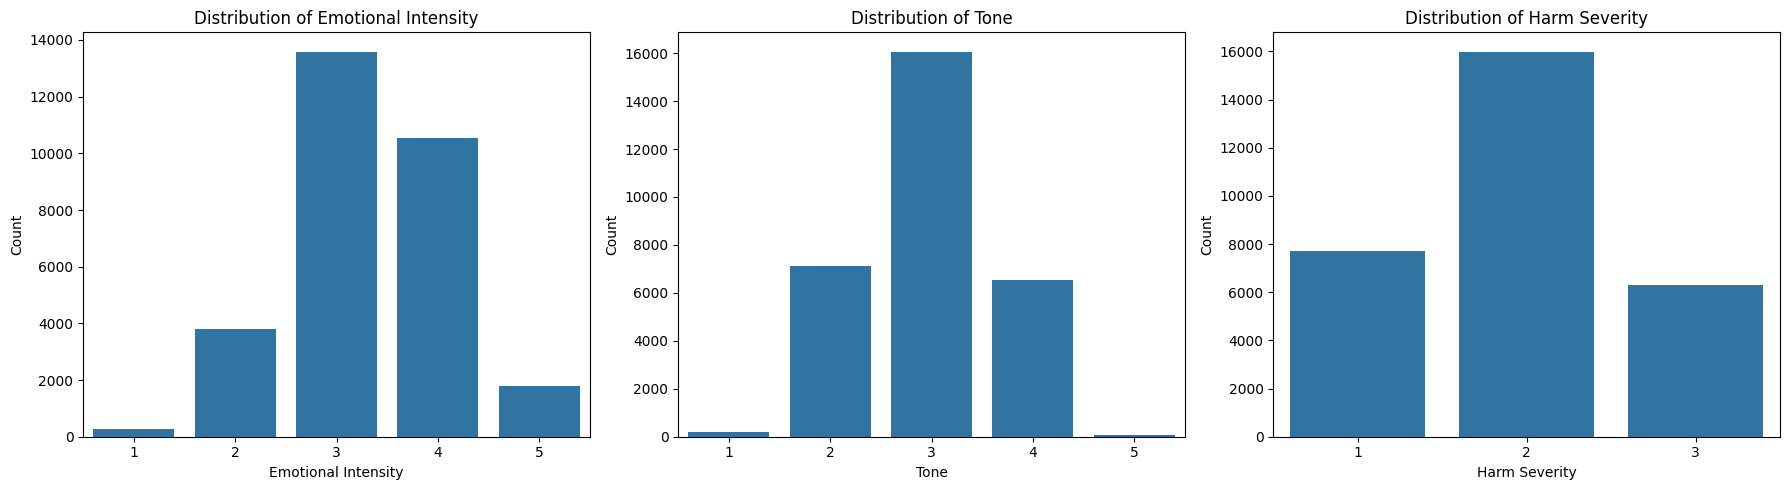

In [ ]:
#PLOT DISTRIBUTION OF SCORES
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(x='emotional_intensity', data=train, ax=axes[0])
axes[0].set_title('Distribution of Emotional Intensity')
axes[0].set_xlabel('Emotional Intensity')
axes[0].set_ylabel('Count')

sns.countplot(x='tone', data=train, ax=axes[1])
axes[1].set_title('Distribution of Tone')
axes[1].set_xlabel('Tone')
axes[1].set_ylabel('Count')

sns.countplot(x='harm_severity', data=train, ax=axes[2])
axes[2].set_title('Distribution of Harm Severity')
axes[2].set_xlabel('Harm Severity')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

## **TRAIN DeBERTa ON THE 30K LABELED SCORES**

Now that the classification went through, we can proceed with fine tuning DeBERTa on the 30k gpt labeled complaints.

In [ ]:
import torch
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("device name:", torch.cuda.get_device_name(0))

cuda available: True
device name: NVIDIA A100-SXM4-40GB


In [ ]:
import torch
from datasets import Dataset
from transformers import AutoTokenizer, AutoConfig, TrainingArguments, Trainer
import torch.nn as nn
from transformers import AutoModel, PreTrainedModel


In [ ]:
#!pip install -q "transformers>=4.40" "datasets>=2.18" accelerate evaluate


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.7 MB/s eta 0:00:00


In [ ]:
#!pip install -U transformers accelerate datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.6/511.6 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 8.7 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: transformers
    Found existing installation: transformers 4.57.2
    Uninstalling transformers-4.57.2:
      Successfully uninstalled transformers-4.57.2
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


In [ ]:
#CONFIGURATION
MODEL_NAME = "microsoft/deberta-v3-base"
TEXT_COL = "Consumer complaint narrative"
MAX_LENGTH = 256  # Lower to 192 if GPU memory is tight

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
# LOAD LABELED 30K
train = pd.read_parquet("cfpb_labeled_30k.parquet")
train_df = train.copy()

print("Columns:", train_df.columns)
print("Size:", len(train_df))

Columns: Index(['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
       'Consumer complaint narrative', 'Company public response', 'Company',
       'State', 'zip', 'Tags', 'Consumer consent provided?', 'Submitted via',
       'Date sent to company', 'Company response to consumer',
       'Timely response?', 'Consumer disputed?', 'Complaint ID', 'Year',
       'GEOGRAPHY', 'ZIP CODE', 'NUMBER OF HOUSEHOLDS',
       'MEDIAN INCOME GENERAL', 'PERCENTAGE WHITE', 'MEDIAN INCOME WHITE',
       'PERCENTAGE BLACK', 'MEDIAN INCOME BLACK', 'PERCENTAGE NATIVE AMERICAN',
       'MEDIAN INCOME NATIVE AMERICAN', 'PERCENTAGE ASIAN',
       'MEDIAN INCOME ASIAN', 'PERCENTAGE HAWAIIAN', 'MEDIAN INCOME HAWAIIAN',
       'PERCENTAGE OTHER RACE', 'MEDIAN INCOME OTHER RACE',
       'PERCENTAGE 2 OR MORE RACES', 'MEDIAN INCOME 2 OR MORE RACES',
       'PERCENTAGE HISPANIC/LATINO ORIGIN (OF ANY RACE)',
       'MEDIAN INCOME HISPANIC/LATINO ORIGIN (OF ANY RACE)',
       'PERCENTAGE WHITE ALON

**1. Clean labels and create 0-based IDs**

In [ ]:
# keep only rows with text + labels
train_df = train_df.dropna(
    subset=[TEXT_COL, "emotional_intensity", "tone", "harm_severity"]
).copy()

# ensure ints
train_df["emotional_intensity"] = train_df["emotional_intensity"].astype(int)
train_df["tone"] = train_df["tone"].astype(int)
train_df["harm_severity"] = train_df["harm_severity"].astype(int)

# 0-based IDs for CrossEntropyLoss (classes start at 0)
train_df["emotion_id"] = train_df["emotional_intensity"] - 1  # 0–4
train_df["tone_id"] = train_df["tone"] - 1                    # 0–4
train_df["harm_id"] = train_df["harm_severity"] - 1           # 0–2

print(train_df[["emotional_intensity", "tone", "harm_severity"]].head())
print("Final training size:", len(train_df))

# small df ONLY for model training
train_for_hf = train_df[[TEXT_COL, "emotion_id", "tone_id", "harm_id"]].copy()


   emotional_intensity  tone  harm_severity
0                    4     3              3
1                    4     4              3
2                    4     4              3
3                    3     3              2
4                    4     3              2
Final training size: 29995


**2. HuggingFace Dataset + tokenization**

In [ ]:
hf_ds = Dataset.from_pandas(train_for_hf)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    enc = tokenizer(
        batch[TEXT_COL],
        truncation=True,
        max_length=MAX_LENGTH,
        padding="max_length",
    )
    enc["label_emotion"] = batch["emotion_id"]
    enc["label_tone"] = batch["tone_id"]
    enc["label_harm"] = batch["harm_id"]
    return enc

hf_ds = hf_ds.map(tokenize_fn, batched=True)

# Train/validation split (90% / 10%)
ds_split = hf_ds.train_test_split(test_size=0.1, seed=42)
train_ds = ds_split["train"]
val_ds = ds_split["test"]

train_ds, val_ds


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Map:   0%|          | 0/29995 [00:00<?, ? examples/s]

(Dataset({
     features: ['Consumer complaint narrative', 'emotion_id', 'tone_id', 'harm_id', 'input_ids', 'token_type_ids', 'attention_mask', 'label_emotion', 'label_tone', 'label_harm'],
     num_rows: 26995
 }),
 Dataset({
     features: ['Consumer complaint narrative', 'emotion_id', 'tone_id', 'harm_id', 'input_ids', 'token_type_ids', 'attention_mask', 'label_emotion', 'label_tone', 'label_harm'],
     num_rows: 3000
 }))

**3. Define multi-task DeBERTa model (3 heads)**

In [ ]:
# base config + extra attributes
config = AutoConfig.from_pretrained(MODEL_NAME)
config.num_emotion_labels = 5
config.num_tone_labels = 5
config.num_harm_labels = 3

class DebertaMultiTaskModel(PreTrainedModel):
    config_class = AutoConfig  # we reuse standard config

    def __init__(self, config):
        super().__init__(config)
        self.deberta = AutoModel.from_pretrained(MODEL_NAME, config=config)
        hidden_size = self.deberta.config.hidden_size

        self.dropout = nn.Dropout(0.1)
        self.emotion_head = nn.Linear(hidden_size, config.num_emotion_labels)
        self.tone_head = nn.Linear(hidden_size, config.num_tone_labels)
        self.harm_head = nn.Linear(hidden_size, config.num_harm_labels)

        self.loss_fct = nn.CrossEntropyLoss()

    def forward(
        self,
        input_ids=None,
        attention_mask=None,
        label_emotion=None,
        label_tone=None,
        label_harm=None,
        **kwargs,
    ):
        outputs = self.deberta(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )
        # CLS-like pooled output
        pooled = outputs.last_hidden_state[:, 0, :]
        pooled = self.dropout(pooled)

        logits_emotion = self.emotion_head(pooled)
        logits_tone = self.tone_head(pooled)
        logits_harm = self.harm_head(pooled)

        loss = None
        if label_emotion is not None and label_tone is not None and label_harm is not None:
            loss_emotion = self.loss_fct(logits_emotion, label_emotion)
            loss_tone = self.loss_fct(logits_tone, label_tone)
            loss_harm = self.loss_fct(logits_harm, label_harm)
            loss = (loss_emotion + loss_tone + loss_harm) / 3.0

        return {
            "loss": loss,
            "logits_emotion": logits_emotion,
            "logits_tone": logits_tone,
            "logits_harm": logits_harm,
        }

model = DebertaMultiTaskModel(config)
print("Model on device:", device)
model.to(device);


pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Model on device: cuda


model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

In [ ]:
from transformers import TrainingArguments, Trainer
import os

os.environ["WANDB_DISABLED"] = "true"
output_dir = "deberta_multitask_cfpb"

training_args = TrainingArguments(
    output_dir=output_dir,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_steps=100,
)

class MultiTaskTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        outputs = model(**inputs)
        loss = outputs["loss"]
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    return {}

trainer = MultiTaskTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

trainer.train()

trainer.save_model(output_dir)
tokenizer.save_pretrained(output_dir)
print("Model saved to", output_dir)


Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
/tmp/ipython-input-453028171.py:26: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `MultiTaskTrainer.__init__`. Use `processing_class` instead.
  trainer = MultiTaskTrainer(


Step,Training Loss
100,1.143500
200,0.994000
300,0.992400
400,0.936900
500,0.895100
600,0.845500
700,0.838600
800,0.863200
900,0.837800
1000,0.829800


Model saved to deberta_multitask_cfpb


In [ ]:
#SAVE MODEL TO DRIVE
#!cp -r deberta_multitask_cfpb /content/drive/MyDrive/

## **VALIDATION**

In [ ]:
from torch.utils.data import DataLoader

# Make sure val_ds returns torch tensors
val_ds.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label_emotion", "label_tone", "label_harm"],
)

val_loader = DataLoader(val_ds, batch_size=32)


In [ ]:
import torch
import numpy as np

model.eval()
model.to(device)

all_emotion_pred = []
all_tone_pred = []
all_harm_pred = []

all_emotion_true = []
all_tone_true = []
all_harm_true = []

with torch.no_grad():
    for batch in val_loader:
        # move batch to GPU
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            label_emotion=None,
            label_tone=None,
            label_harm=None,
        )

        emo_logits = outputs["logits_emotion"].cpu().numpy()
        tone_logits = outputs["logits_tone"].cpu().numpy()
        harm_logits = outputs["logits_harm"].cpu().numpy()

        emo_pred = emo_logits.argmax(axis=1)
        tone_pred = tone_logits.argmax(axis=1)
        harm_pred = harm_logits.argmax(axis=1)

        all_emotion_pred.extend(emo_pred.tolist())
        all_tone_pred.extend(tone_pred.tolist())
        all_harm_pred.extend(harm_pred.tolist())

        all_emotion_true.extend(batch["label_emotion"].cpu().numpy().tolist())
        all_tone_true.extend(batch["label_tone"].cpu().numpy().tolist())
        all_harm_true.extend(batch["label_harm"].cpu().numpy().tolist())

all_emotion_pred = np.array(all_emotion_pred)
all_tone_pred = np.array(all_tone_pred)
all_harm_pred = np.array(all_harm_pred)

all_emotion_true = np.array(all_emotion_true)
all_tone_true = np.array(all_tone_true)
all_harm_true = np.array(all_harm_true)

len(all_emotion_true), len(val_ds)


(3000, 3000)

In [ ]:
def accuracy(y_true, y_pred):
    return (y_true == y_pred).mean()

emo_acc = accuracy(all_emotion_true, all_emotion_pred)
tone_acc = accuracy(all_tone_true, all_tone_pred)
harm_acc = accuracy(all_harm_true, all_harm_pred)

print(f"Validation accuracy - emotional_intensity (exact): {emo_acc:.3f}")
print(f"Validation accuracy - tone (exact):              {tone_acc:.3f}")
print(f"Validation accuracy - harm_severity (exact):     {harm_acc:.3f}")

# For ordinal labels: how often within ±1 of GPT label
emo_within1 = (np.abs(all_emotion_true - all_emotion_pred) <= 1).mean()
harm_within1 = (np.abs(all_harm_true - all_harm_pred) <= 1).mean()

print(f"Emotional intensity within ±1: {emo_within1:.3f}")
print(f"Harm severity within ±1:       {harm_within1:.3f}")


Validation accuracy - emotional_intensity (exact): 0.667
Validation accuracy - tone (exact):              0.701
Validation accuracy - harm_severity (exact):     0.701
Emotional intensity within ±1: 0.993
Harm severity within ±1:       0.994


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print("Emotion classification report:")
print(classification_report(all_emotion_true, all_emotion_pred, digits=3))

print("Tone classification report:")
print(classification_report(all_tone_true, all_tone_pred, digits=3))

print("Harm severity classification report:")
print(classification_report(all_harm_true, all_harm_pred, digits=3))

Emotion classification report:
              precision    recall  f1-score   support

           0      0.667     0.357     0.465        28
           1      0.649     0.501     0.566       387
           2      0.681     0.736     0.707      1344
           3      0.658     0.691     0.674      1046
           4      0.642     0.441     0.523       195

    accuracy                          0.667      3000
   macro avg      0.659     0.545     0.587      3000
weighted avg      0.666     0.667     0.663      3000

Tone classification report:
              precision    recall  f1-score   support

           0      0.833     0.250     0.385        20
           1      0.713     0.621     0.664       713
           2      0.693     0.807     0.746      1569
           3      0.711     0.561     0.627       693
           4      0.000     0.000     0.000         5

    accuracy                          0.701      3000
   macro avg      0.590     0.448     0.484      3000
weighted avg      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## **LABEL THE WHOLE DATASET**

In [ ]:
import torch
import numpy as np

from transformers import AutoTokenizer, AutoConfig, AutoModel, PreTrainedModel
import torch.nn as nn
from tqdm import tqdm

# Columns
TEXT_COL = "Consumer complaint narrative"
ID_COL = "Complaint ID"

# Model paths
BASE_MODEL_NAME = "microsoft/deberta-v3-base"
MODEL_PATH = "/content/drive/MyDrive/deberta_multitask_cfpb"  # the saved fine-tuned model

MAX_LENGTH = 256

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [ ]:
# Full dataset
full_df = zip_data_16_23_filtered.copy()
full_df = full_df.dropna(subset=[TEXT_COL, ID_COL]).copy()
full_df[ID_COL] = full_df[ID_COL].astype(str)
full_df.reset_index(drop=True, inplace=True)
print("Full dataset size:", len(full_df))

# 30k GPT-labeled
train_30k = train.copy()
train_30k = train_30k.dropna(subset=[TEXT_COL, ID_COL]).copy()
train_30k[ID_COL] = train_30k[ID_COL].astype(str)
print("Labeled 30k size:", len(train_30k))

# IDs already labeled by GPT
llm_ids = set(train_30k[ID_COL].unique())

# Subset of full_df that does NOT have GPT labels
mask_not_llm = ~full_df[ID_COL].isin(llm_ids)
infer_df = full_df[mask_not_llm].copy().reset_index(drop=True)

print("To classify with DeBERTa:", len(infer_df))
print("Already labeled with GPT:", len(llm_ids))


Full dataset size: 439847
Labeled 30k size: 29995
To classify with DeBERTa: 409852
Already labeled with GPT: 29995


In [ ]:
# tokenizer + config from base model
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_NAME)
config = AutoConfig.from_pretrained(BASE_MODEL_NAME)

# Add custom attributes
config.num_emotion_labels = 5
config.num_tone_labels = 5
config.num_harm_labels = 3

class DebertaMultiTaskModel(PreTrainedModel):
    config_class = AutoConfig

    def __init__(self, config):
        super().__init__(config)
        self.deberta = AutoModel.from_pretrained(BASE_MODEL_NAME, config=config)
        hidden_size = self.deberta.config.hidden_size

        self.dropout = nn.Dropout(0.1)
        self.emotion_head = nn.Linear(hidden_size, config.num_emotion_labels)
        self.tone_head = nn.Linear(hidden_size, config.num_tone_labels)
        self.harm_head = nn.Linear(hidden_size, config.num_harm_labels)

        self.loss_fct = nn.CrossEntropyLoss()

    def forward(
        self,
        input_ids=None,
        attention_mask=None,
        label_emotion=None,
        label_tone=None,
        label_harm=None,
        **kwargs,
    ):
        outputs = self.deberta(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )
        pooled = outputs.last_hidden_state[:, 0, :]
        pooled = self.dropout(pooled)

        logits_emotion = self.emotion_head(pooled)
        logits_tone = self.tone_head(pooled)
        logits_harm = self.harm_head(pooled)

        loss = None
        if label_emotion is not None and label_tone is not None and label_harm is not None:
            loss_emotion = self.loss_fct(logits_emotion, label_emotion)
            loss_tone = self.loss_fct(logits_tone, label_tone)
            loss_harm = self.loss_fct(logits_harm, label_harm)
            loss = (loss_emotion + loss_tone + loss_harm) / 3.0

        return {
            "loss": loss,
            "logits_emotion": logits_emotion,
            "logits_tone": logits_tone,
            "logits_harm": logits_harm,
        }

# Load fine-tuned weights from Drive
inference_model = DebertaMultiTaskModel.from_pretrained(MODEL_PATH, config=config).to(device)
inference_model.eval()

print("Model loaded and ready.")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

Model loaded and ready.


In [ ]:
BATCH_SIZE = 32

all_emo_pred = []
all_tone_pred = []
all_harm_pred = []

for start in tqdm(range(0, len(infer_df), BATCH_SIZE)):
    end = min(start + BATCH_SIZE, len(infer_df))
    batch_texts = infer_df[TEXT_COL].iloc[start:end].tolist()

    enc = tokenizer(
        batch_texts,
        truncation=True,
        max_length=MAX_LENGTH,
        padding="max_length",
        return_tensors="pt",
    ).to(device)

    with torch.no_grad():
        outputs = inference_model(
            input_ids=enc["input_ids"],
            attention_mask=enc["attention_mask"],
            label_emotion=None,
            label_tone=None,
            label_harm=None,
        )

    emo_logits = outputs["logits_emotion"].cpu().numpy()
    tone_logits = outputs["logits_tone"].cpu().numpy()
    harm_logits = outputs["logits_harm"].cpu().numpy()

    emo_pred_ids = emo_logits.argmax(axis=1)
    tone_pred_ids = tone_logits.argmax(axis=1)
    harm_pred_ids = harm_logits.argmax(axis=1)

    # convert 0-based → 1-based like GPT labels
    all_emo_pred.extend((emo_pred_ids + 1).tolist())
    all_tone_pred.extend((tone_pred_ids + 1).tolist())
    all_harm_pred.extend((harm_pred_ids + 1).tolist())

len(all_emo_pred), len(infer_df)


100%|██████████| 12808/12808 [31:10<00:00,  6.85it/s]


(409852, 409852)

In [ ]:
infer_df["emo_pred"] = all_emo_pred
infer_df["tone_pred"] = all_tone_pred
infer_df["harm_pred"] = all_harm_pred



Merge GPT labels + DeBERTa predictions → final labels


In [ ]:
pred_cols = [ID_COL, "emo_pred", "tone_pred", "harm_pred"]

full_df = full_df.merge(
    infer_df[pred_cols],
    on=ID_COL,
    how="left",
)


In [ ]:
#Bring in GPT labels from train_30k
llm_df = train_30k[[ID_COL, "emotional_intensity", "tone", "harm_severity"]].copy()
llm_df = llm_df.rename(columns={
    "emotional_intensity": "emo_llm",
    "tone": "tone_llm",
    "harm_severity": "harm_llm",
})

full_df = full_df.merge(llm_df, on=ID_COL, how="left")

In [ ]:
# Use GPT labels when available, else DeBERTa predictions
full_df["emo_final"]  = full_df["emo_llm"].fillna(full_df["emo_pred"])
full_df["tone_final"] = full_df["tone_llm"].fillna(full_df["tone_pred"])
full_df["harm_final"] = full_df["harm_llm"].fillna(full_df["harm_pred"])

# Ensure integer
full_df["emo_final"]  = full_df["emo_final"].astype(int)
full_df["tone_final"] = full_df["tone_final"].astype(int)
full_df["harm_final"] = full_df["harm_final"].astype(int)

print(full_df[["emo_final", "tone_final", "harm_final"]].isna().sum())


emo_final     0
tone_final    0
harm_final    0
dtype: int64


In [ ]:
full_df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,zip,...,MEDIAN INCOME HOUSEHOLDER 65+ YO,emo_pred,tone_pred,harm_pred,emo_llm,tone_llm,harm_llm,emo_final,tone_final,harm_final
0,03/17/22,"Credit reporting, credit repair services, or o...",Credit reporting,Improper use of your report,Reporting company used your report improperly,In accordance with the Fair Credit Reporting A...,NaN,"EQUIFAX, INC.",FL,32506,...,46235,3.0,3.0,2.0,NaN,NaN,NaN,3,3,2
1,01/31/19,"Credit reporting, credit repair services, or o...",Credit reporting,Problem with a credit reporting company's inve...,Problem with personal statement of dispute,on XX/XX/XXXX I applied for a XXXX XXXX Reward...,NaN,"EQUIFAX, INC.",CA,94568,...,72703,3.0,3.0,2.0,NaN,NaN,NaN,3,3,2
2,07/18/23,"Credit reporting, credit repair services, or o...",Credit reporting,Improper use of your report,Reporting company used your report improperly,the list of inquries listed below are a result...,NaN,"EQUIFAX, INC.",SC,29115,...,28771,3.0,3.0,2.0,NaN,NaN,NaN,3,3,2
3,01/05/23,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Information belongs to someone else,This is my NUMEROUS request that I have been a...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",CA,94806,...,62069,4.0,3.0,2.0,NaN,NaN,NaN,4,3,2
4,10/17/17,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Account information incorrect,I have disputed this Account on many occasions...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",NC,27705,...,50038,3.0,3.0,2.0,NaN,NaN,NaN,3,3,2


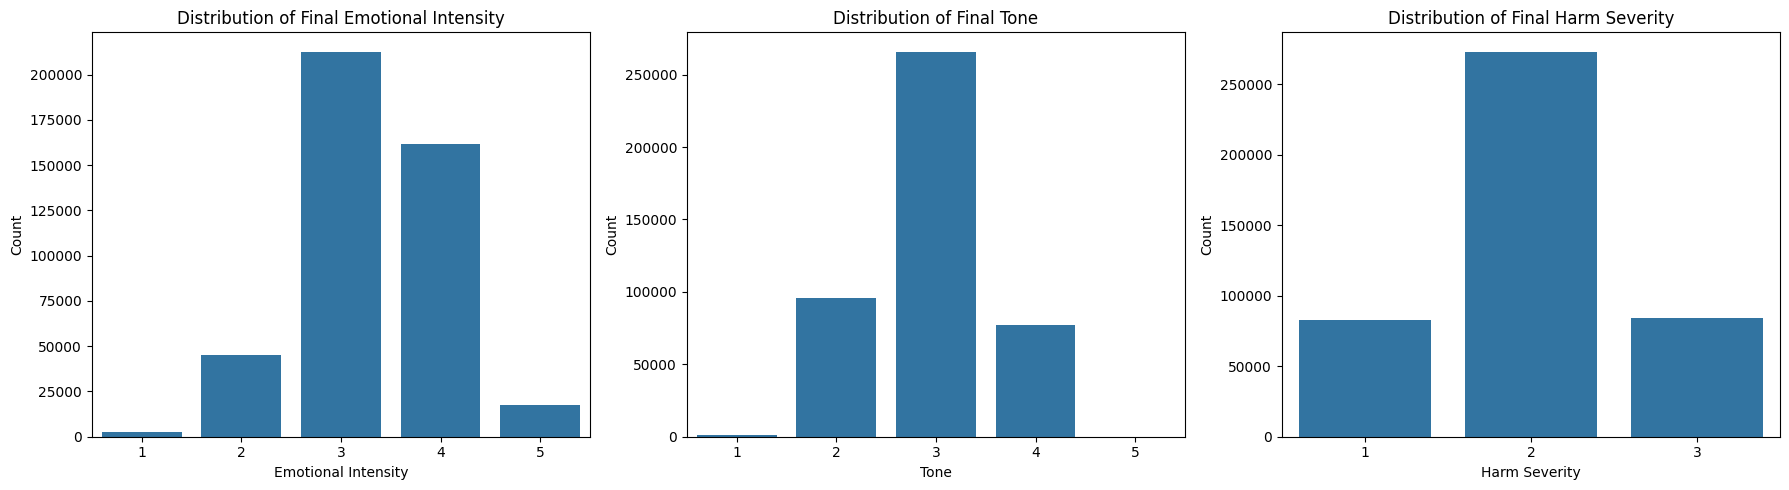

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(x='emo_final', data=full_df, ax=axes[0])
axes[0].set_title('Distribution of Final Emotional Intensity')
axes[0].set_xlabel('Emotional Intensity')
axes[0].set_ylabel('Count')

sns.countplot(x='tone_final', data=full_df, ax=axes[1])
axes[1].set_title('Distribution of Final Tone')
axes[1].set_xlabel('Tone')
axes[1].set_ylabel('Count')

sns.countplot(x='harm_final', data=full_df, ax=axes[2])
axes[2].set_title('Distribution of Final Harm Severity')
axes[2].set_xlabel('Harm Severity')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [ ]:
len(full_df)

439847

In [ ]:
full_df.to_parquet("cfpb_full_with_final_labels.parquet", index=False)
print("Saved cfpb_full_with_final_labels.parquet")

Saved cfpb_full_with_final_labels.parquet


## **MERGE WITH AI LABELS**

In [3]:
import pyarrow.parquet as pq
pq.ParquetFile("/content/drive/MyDrive/cfpb_full_with_final_labels.parquet")
full_data = pd.read_parquet("/content/drive/MyDrive/cfpb_full_with_final_labels.parquet")

In [4]:
full_data['Date received'] = pd.to_datetime(
    full_data['Date received'],
    format='%m/%d/%y',   # explicit format
    errors='coerce'      # bad values become NaT
)


In [6]:
AI_label = pd.read_excel("/content/drive/MyDrive/banks_ai_label.xlsx", sheet_name= 'CHATGPT')
AI_label.head()

,Institution Name,ChatBot CHATGPT (Yes/No/Unknown),ChatBot GEMINI (Yes/No/Unknown),Chatbot Name CHATGPT,Chatbot Name GEMINI,Treatment Date (T0) CHAT GPT,Treatment Date (T0) GEMINI,Implication for study (CHATGPT)
0,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",NO,NO,NaN,NaN,NaN,NaN,"Support options show phone, online forms and F..."
1,"EQUIFAX, INC.",NO,NO,–,NaN,NaN,NaN,Contact channels are phone and web forms; no s...
2,Experian Information Solutions Inc.,NO,NO,NaN,NaN,NaN,NaN,Databricks case study describes Experian build...
3,CAPITAL ONE FINANCIAL CORPORATION,Yes,Yes,Eno,Eno,2017-03-01 00:00:00,2017-03-01 00:00:00,"Capital One launched “Eno”, a natural-language..."
4,JPMORGAN CHASE & CO.,Yes,Yes,Chase Digital Assistant,Chase Digital Assistant,2020-11-01 00:00:00,2020-11-01 00:00:00,Consumer brand Chase introduced “Chase Digital...


In [7]:
#now apply some changes to the dataset (drop useless colums and fix date columns.)
AI_label.drop(columns=['ChatBot GEMINI (Yes/No/Unknown)', 'Chatbot Name GEMINI', 'Treatment Date (T0) GEMINI'], inplace=True)
AI_label.rename(columns={'ChatBot CHATGPT (Yes/No/Unknown)': 'AI adoption', 'Chatbot Name CHATGPT' : 'Chatbot name', 'Treatment Date (T0) CHAT GPT':'Date introduction'}, inplace=True)
AI_label.head()

,Institution Name,AI adoption,Chatbot name,Date introduction,Implication for study (CHATGPT)
0,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",NO,NaN,NaN,"Support options show phone, online forms and F..."
1,"EQUIFAX, INC.",NO,–,NaN,Contact channels are phone and web forms; no s...
2,Experian Information Solutions Inc.,NO,NaN,NaN,Databricks case study describes Experian build...
3,CAPITAL ONE FINANCIAL CORPORATION,Yes,Eno,2017-03-01 00:00:00,"Capital One launched “Eno”, a natural-language..."
4,JPMORGAN CHASE & CO.,Yes,Chase Digital Assistant,2020-11-01 00:00:00,Consumer brand Chase introduced “Chase Digital...


In [8]:
AI_label['Date introduction'].unique()

array([nan, datetime.datetime(2017, 3, 1, 0, 0),
       datetime.datetime(2020, 11, 1, 0, 0),
       datetime.datetime(2022, 10, 1, 0, 0),
       datetime.datetime(2018, 6, 1, 0, 0),
       datetime.datetime(2018, 1, 1, 0, 0),
       datetime.datetime(2018, 10, 1, 0, 0),
       datetime.datetime(2016, 9, 1, 0, 0), 'Uknown',
       datetime.datetime(2020, 7, 1, 0, 0), 'PRE',
       datetime.datetime(2019, 1, 1, 0, 0),
       datetime.datetime(2015, 5, 1, 0, 0),
       datetime.datetime(2019, 10, 1, 0, 0),
       datetime.datetime(2022, 9, 1, 0, 0),
       datetime.datetime(2016, 1, 1, 0, 0), 'POST', 2024,
       datetime.datetime(2016, 3, 1, 0, 0),
       datetime.datetime(2020, 5, 1, 0, 0),
       datetime.datetime(2019, 5, 1, 0, 0),
       datetime.datetime(2021, 3, 1, 0, 0),
       datetime.datetime(2018, 3, 1, 0, 0), ' ',
       datetime.datetime(2019, 2, 1, 0, 0),
       datetime.datetime(2020, 1, 1, 0, 0), 2023,
       datetime.datetime(2018, 5, 1, 0, 0), 2022, 2020,
       dateti

Let's fix some of this data.
- Those that implemented AI Chatbots before 2016 (our beginning date) are set with the date 01/01/2016.
- Those that implemented AI Chatbots after 2023 (our ending date) are set as NaN --> no adoption
- Those for which we only have an eveidence of the year we set them as the first day of that year.
- We keep the Uknown at the moment.

In [10]:

import re


df = AI_label

# Standardize column as string first
df['Date introduction'] = df['Date introduction'].astype(str).str.strip()

def clean_date(val):
    # Rule 1: PRE → 2016-01-01 (as datetime)
    if val == "PRE":
        return pd.Timestamp("2016-01-01")

    # Rule 2: Unknown → keep as Unknown (string)
    if val.lower() == "uknown":
        return "Unknown"   # we keep Unknown as string per your rule

    # Rule 3: POST → NaN
    if val == "POST":
        return np.nan

    # Rule 4: blank / whitespace → NaN
    if val.strip() == "":
        return np.nan

    # Rule 5: Only a year (e.g. "2015") → create datetime
    if re.fullmatch(r"\d{4}", val):
        return pd.Timestamp(f"{val}-01-01")

    # Otherwise try to convert to datetime
    try:
        return pd.to_datetime(val)
    except:
        return np.nan

# Apply cleaning
df['Date introduction Clean'] = df['Date introduction'].apply(clean_date)


In [11]:
df['Date introduction Clean'].unique()

array([NaT, Timestamp('2017-03-01 00:00:00'),
       Timestamp('2020-11-01 00:00:00'), Timestamp('2022-10-01 00:00:00'),
       Timestamp('2018-06-01 00:00:00'), Timestamp('2018-01-01 00:00:00'),
       Timestamp('2018-10-01 00:00:00'), Timestamp('2016-09-01 00:00:00'),
       'Unknown', Timestamp('2020-07-01 00:00:00'),
       Timestamp('2016-01-01 00:00:00'), Timestamp('2019-01-01 00:00:00'),
       Timestamp('2015-05-01 00:00:00'), Timestamp('2019-10-01 00:00:00'),
       Timestamp('2022-09-01 00:00:00'), nan,
       Timestamp('2024-01-01 00:00:00'), Timestamp('2016-03-01 00:00:00'),
       Timestamp('2020-05-01 00:00:00'), Timestamp('2019-05-01 00:00:00'),
       Timestamp('2021-03-01 00:00:00'), Timestamp('2018-03-01 00:00:00'),
       Timestamp('2019-02-01 00:00:00'), Timestamp('2020-01-01 00:00:00'),
       Timestamp('2023-01-01 00:00:00'), Timestamp('2018-05-01 00:00:00'),
       Timestamp('2022-01-01 00:00:00'), Timestamp('2023-03-01 00:00:00'),
       Timestamp('2017-11-01 00

In [12]:
df.head()

,Institution Name,AI adoption,Chatbot name,Date introduction,Implication for study (CHATGPT),Date introduction Clean
0,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",NO,NaN,nan,"Support options show phone, online forms and F...",NaT
1,"EQUIFAX, INC.",NO,–,nan,Contact channels are phone and web forms; no s...,NaT
2,Experian Information Solutions Inc.,NO,NaN,nan,Databricks case study describes Experian build...,NaT
3,CAPITAL ONE FINANCIAL CORPORATION,Yes,Eno,2017-03-01 00:00:00,"Capital One launched “Eno”, a natural-language...",2017-03-01 00:00:00
4,JPMORGAN CHASE & CO.,Yes,Chase Digital Assistant,2020-11-01 00:00:00,Consumer brand Chase introduced “Chase Digital...,2020-11-01 00:00:00


In [13]:
len(df)


233

We append the introduction date in full_data.

In [14]:
lookup_dict = df.set_index('Institution Name')['Date introduction Clean'].to_dict()

In [15]:
full_data['AI_introduction'] = full_data['Company'].map(lookup_dict)


In [16]:
full_data['Date received'] =  pd.to_datetime(full_data['Date received'], errors = 'coerce')

In [17]:
full_data[full_data['Date received'] == full_data['Date received'].min()]

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,zip,...,emo_pred,tone_pred,harm_pred,emo_llm,tone_llm,harm_llm,emo_final,tone_final,harm_final,AI_introduction
23125,2015-03-19,Mortgage,Conventional fixed mortgage,"Loan servicing, payments, escrow account",None,I spoke to XXXX of green tree representatives ...,None,Ditech Financial LLC,CA,94806,...,NaN,NaN,NaN,3.0,3.0,2.0,3,3,2,NaT
24367,2015-03-19,Credit reporting,None,Incorrect information on credit report,Account status,Majority of delinquent accounts occurred over ...,Company chooses not to provide a public response,Experian Information Solutions Inc.,FL,33558,...,3.0,2.0,2.0,NaN,NaN,NaN,3,2,2,NaT
32407,2015-03-19,Bank account or service,Checking account,"Account opening, closing, or management",None,I signed up for a PNC account on XXXX XXXX 201...,None,PNC Bank N.A.,PA,19150,...,3.0,3.0,1.0,NaN,NaN,NaN,3,3,1,Unknown
43463,2015-03-19,Credit reporting,None,Incorrect information on credit report,Account status,I have submitted XXXX disputes to Trans Union ...,None,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",FL,33157,...,3.0,3.0,2.0,NaN,NaN,NaN,3,3,2,NaT
82174,2015-03-19,Debt collection,I do not know,Cont'd attempts collect debt not owed,Debt is not mine,This company continues to report on my credit ...,None,ERC,TX,77536,...,NaN,NaN,NaN,4.0,4.0,3.0,4,4,3,NaT
87298,2015-03-19,Credit reporting,None,Unable to get credit report/credit score,Problem getting my free annual report,Experian refused to provide free annual credit...,Company chooses not to provide a public response,Experian Information Solutions Inc.,LA,70124,...,3.0,3.0,1.0,NaN,NaN,NaN,3,3,1,NaT
110868,2015-03-19,Consumer Loan,Installment loan,Managing the loan or lease,None,They are not applying my extra loan payments t...,Company disputes the facts presented in the co...,"MARINER FINANCE, LLC",FL,33068,...,3.0,3.0,2.0,NaN,NaN,NaN,3,3,2,NaT
113031,2015-03-19,Mortgage,Conventional fixed mortgage,"Loan modification,collection,foreclosure",None,In XX/XX/XXXX my wages that I earned at my job...,None,WELLS FARGO & COMPANY,CA,94608,...,4.0,3.0,3.0,NaN,NaN,NaN,4,3,3,2022-10-01 00:00:00
113152,2015-03-19,Student loan,Non-federal student loan,Can't repay my loan,Can't decrease my monthly payments,I am trying to deal with Navient ( formerly XX...,None,"Navient Solutions, LLC.",NY,14223,...,NaN,NaN,NaN,4.0,3.0,3.0,4,3,3,NaT
114087,2015-03-19,Student loan,Non-federal student loan,Dealing with my lender or servicer,Having problems with customer service,My daughter 's father passe away and XXXX of h...,None,WELLS FARGO & COMPANY,CA,91364,...,4.0,3.0,2.0,NaN,NaN,NaN,4,3,2,2022-10-01 00:00:00


In [18]:
#now we create the AI_dummy. 1 if the the company introduced chatbot before the complaint, 0 otherwise.

def compute_ai_dummy(received, intro):

    # 1. Unknown stays Unknown
    if isinstance(intro, str) and intro.lower() == "unknown":
        return "Unknown"

    # 2. NaN or NaT → 0
    if pd.isna(intro):
        return 0

    # 3. intro is a datetime → compare
    if received < intro:
        return 0
    else:
        return 1

# Apply row by row
full_data['AI_dummy'] = full_data.apply(
    lambda row: compute_ai_dummy(row['Date received'], row['AI_introduction']),
    axis=1
)


In [ ]:
full_data['AI_dummy'].unique()

array([0, 1, 'Unknown'], dtype=object)

In [19]:
full_data['AI_overall'] = full_data['AI_introduction'].notna().astype(int)


In [20]:
len(full_data[full_data['AI_introduction'] == 'Unknown'])

8707

In [21]:
full_data['AI_dummy'].value_counts()

,count
AI_dummy,
0,367633
1,63507
Unknown,8707


In [22]:
full_data['AI_overall'].value_counts()

,count
AI_overall,
0,337094
1,102753


In [ ]:
full_data.to_csv('full_data.csv')